# 01. Analysis Setup

### What are we trying to understand?

This project evaluates the effectiveness of an advertising experiment by comparing users exposed to an **Advertisement** with users shown a **Public Service Announcement (PSA)**. We then investigate whether the level and timing of ad exposure are associated with differences in conversion behavior.

The analysis follows a business-focused path: **validate the experiment data → measure overall campaign impact → understand exposure levels → identify when and where conversion is strongest**.


In [1]:
import numpy as np
import pandas as pd 

### Load the Experiment Data

We begin by loading the raw marketing experiment dataset. Establishing the raw data first allows us to inspect its structure and verify that the fields needed for experiment, exposure, and conversion analysis are available.


In [2]:
df = pd.read_csv('marketing_AB.csv')

### Initial Data Inspection

Before transforming or analyzing the data, we inspect the first and last observations. This provides a quick check of the dataset's structure and helps confirm that the imported records look consistent with the expected marketing experiment.


In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.tail()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


# 02. Data Preparation

### Standardize the Dataset for Analysis

We clean the column names and replace the technical index field with a meaningful name. Consistent naming makes the dataset easier to query and reduces ambiguity when building the analysis that follows.


In [5]:
df = df.rename(columns={'Unnamed: 0': 'serial_number'})

In [6]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', '_', regex=True)
)

### Make Experiment Groups Business-Readable

The raw experiment uses abbreviated group labels. We translate these into descriptive business terms so that subsequent results and visualizations can be interpreted directly by a non-technical stakeholder.


In [7]:
# Finding the unique values and changing them to meaningful values

In [8]:
df['test_group'].unique()

<StringArray>
['ad', 'psa']
Length: 2, dtype: str

In [9]:
df['test_group'] = df['test_group'].replace({
    'ad': 'Advertisement',
    'psa': 'Public Service Announcement'
})

In [10]:
df.head()

,serial_number,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,Advertisement,False,130,Monday,20
1,1,1119715,Advertisement,False,93,Tuesday,22
2,2,1144181,Advertisement,False,21,Tuesday,18
3,3,1435133,Advertisement,False,355,Tuesday,10
4,4,1015700,Advertisement,False,276,Friday,14


# 03. Data Quality & Experiment Validation

### Can We Trust the Data Before Measuring Campaign Impact?

Before comparing conversion rates, we validate the basic quality of the experiment dataset. We check data types, missing values, group distribution, duplicate users, and the plausibility of key exposure variables.

This is important because an apparent difference between the Advertisement and PSA groups is only useful if the underlying data is complete, consistently structured, and represents users appropriately.


In [11]:
# Checking for data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   serial_number  588101 non-null  int64
 1   user_id        588101 non-null  int64
 2   test_group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total_ads      588101 non-null  int64
 5   most_ads_day   588101 non-null  str  
 6   most_ads_hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


In [12]:
#Checking for missing values
print(df.isnull().sum())

serial_number    0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


In [13]:
# Checking channel distribution 
df['test_group'].value_counts(normalize=True)

test_group
Advertisement                  0.96
Public Service Announcement    0.04
Name: proportion, dtype: float64

In [14]:
# check for duplicates
df['user_id'].duplicated().sum()

np.int64(0)

### Sanity-Check Ad Exposure

We inspect the possible values and distribution of ad exposure variables to understand the range of user behavior. This helps identify unusual values and establishes the basis for segmenting users by exposure level later in the analysis.


In [15]:
# Checking sanity

In [16]:
df['most_ads_hour'].unique()

array([20, 22, 18, 10, 14, 13, 19, 11, 12, 16, 21,  3, 23,  4,  8,  0,  2,
       15,  1,  6, 17,  7,  9,  5])

In [17]:
df['most_ads_day'].unique()

<StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str

In [18]:
df['total_ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64

# 04. Campaign Effectiveness

### Business Question: Did Advertising Actually Increase Conversion?

The first business question is whether users exposed to the Advertisement converted at a different rate from users in the PSA control group.

We calculate conversion rates for both groups and use a **two-proportion statistical test with a 95% confidence interval**. This moves the analysis beyond a simple percentage comparison and helps determine whether the observed difference is statistically meaningful.


In [19]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Get counts per group
ad = df[df['test_group'] == 'Advertisement']
psa = df[df['test_group'] == 'Public Service Announcement']

ad_conversions = ad['converted'].sum()
ad_total = ad['converted'].count()

psa_conversions = psa['converted'].sum()
psa_total = psa['converted'].count()

print(f"Ad group: {ad_conversions} / {ad_total} = {ad_conversions/ad_total:.4%}")
print(f"PSA group: {psa_conversions} / {psa_total} = {psa_conversions/psa_total:.4%}")

# Two-proportion z-test
count = [ad_conversions, psa_conversions]
nobs = [ad_total, psa_total]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# 95% confidence interval on the difference in proportions
ci_low, ci_upp = confint_proportions_2indep(
    ad_conversions, ad_total,
    psa_conversions, psa_total,
    method='wald'
)
print(f"\n95% CI for difference (ad - psa): [{ci_low:.4%}, {ci_upp:.4%}]")

Ad group: 14423 / 564577 = 2.5547%
PSA group: 420 / 23524 = 1.7854%

Z-statistic: 7.3701
P-value: 0.000000

95% CI for difference (ad - psa): [0.5951%, 0.9434%]


# 05. Ad Exposure Analysis

### Business Question: How Is Ad Exposure Distributed Across Users?

A campaign-level conversion comparison tells us whether advertising worked overall, but it does not explain how exposure is distributed. We examine the distribution of ads seen per user and inspect the long tail of highly exposed users.

Understanding this distribution is necessary before creating meaningful exposure segments and prevents the extreme upper end from being hidden by the overall average.


count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64


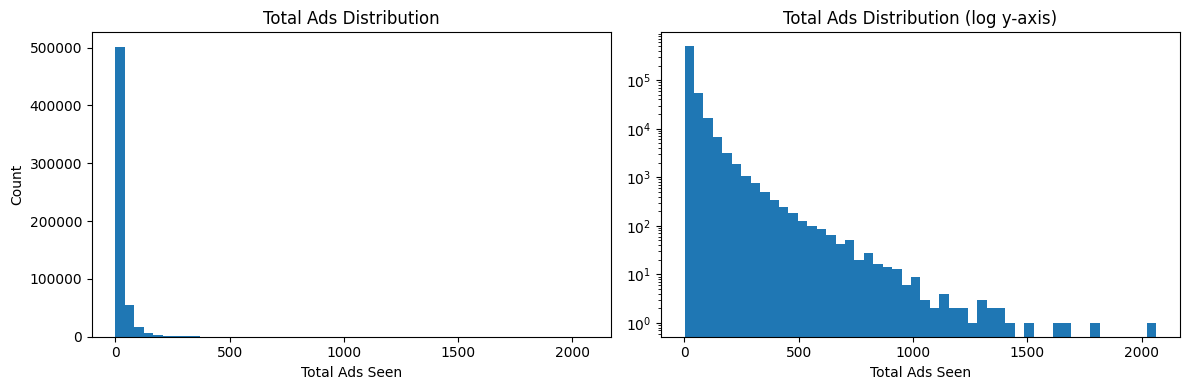

0.500     13.0
0.750     27.0
0.900     57.0
0.950     88.0
0.990    202.0
0.999    499.9
Name: total_ads, dtype: float64


In [20]:
import matplotlib.pyplot as plt

print(df['total_ads'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regular scale
axes[0].hist(df['total_ads'], bins=50)
axes[0].set_title('Total Ads Distribution')
axes[0].set_xlabel('Total Ads Seen')
axes[0].set_ylabel('Count')

# Log scale - to actually see the shape given the skew
axes[1].hist(df['total_ads'], bins=50)
axes[1].set_yscale('log')
axes[1].set_title('Total Ads Distribution (log y-axis)')
axes[1].set_xlabel('Total Ads Seen')

plt.tight_layout()
plt.show()

# Check how extreme the top end is
print(df['total_ads'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999]))

### Create Actionable Exposure Segments

The exposure distribution is highly skewed, so individual ad counts are converted into practical exposure buckets. These segments make it easier to compare conversion behavior across low, moderate, high, and very high exposure groups and turn a continuous metric into an interpretable business view.


In [21]:
bins = [0, 3, 13, 27, 57, 2065]
labels = ['1-3 (low)', '4-13 (below median)', '14-27 (above median)', '28-57 (high)', '58+ (very high)']

df['ads_bucket'] = pd.cut(df['total_ads'], bins=bins, labels=labels, include_lowest=True)

print(df['ads_bucket'].value_counts().sort_index())
print(df.groupby('ads_bucket', observed=True)['total_ads'].agg(['min','max','count']))

ads_bucket
1-3 (low)               125094
4-13 (below median)     174402
14-27 (above median)    142757
28-57 (high)             88402
58+ (very high)          57446
Name: count, dtype: int64
                      min   max   count
ads_bucket                             
1-3 (low)               1     3  125094
4-13 (below median)     4    13  174402
14-27 (above median)   14    27  142757
28-57 (high)           28    57   88402
58+ (very high)        58  2065   57446


# 06. Exposure vs. Conversion

### Business Question: Does More Ad Exposure Lead to More Conversions?

We now focus only on users who actually received advertisements, since PSA users do not have meaningful ad-exposure values.

By comparing conversion rates across exposure buckets, we can investigate whether conversion changes as users see more ads. This helps distinguish a simple campaign effect from a potential **exposure-response relationship** and provides a basis for thinking about campaign efficiency.


                      conversion_rate  n_users
ads_bucket                                    
1-3 (low)                    0.002125   119537
4-13 (below median)          0.004930   167358
14-27 (above median)         0.011863   137483
28-57 (high)                 0.043204    85178
58+ (very high)              0.145999    55021


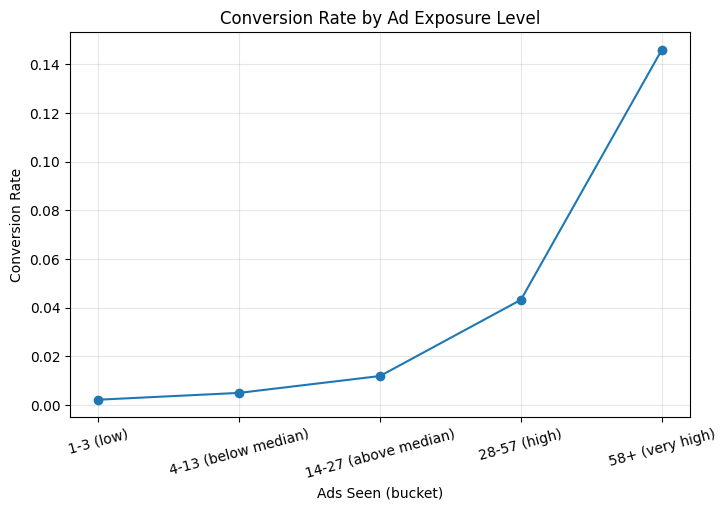

In [22]:
# Only look within the ad group (PSA users didn't get ads, so exposure doesn't apply)
ad_only = df[df['test_group'] == 'Advertisement']

dose_response = ad_only.groupby('ads_bucket', observed=True)['converted'].agg(['mean', 'count'])
dose_response.columns = ['conversion_rate', 'n_users']
print(dose_response)

# Visualize
plt.figure(figsize=(8,5))
plt.plot(dose_response.index, dose_response['conversion_rate'], marker='o')
plt.title('Conversion Rate by Ad Exposure Level')
plt.xlabel('Ads Seen (bucket)')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=15)
plt.grid(alpha=0.3)
plt.show()

### Business Question: Where Are Conversions Concentrated?

The exposure analysis is also useful from a campaign allocation perspective. We quantify how much of the total advertising-group conversion volume comes from the very-high-exposure segment and compare that contribution with the size of the user segment.

This helps assess whether a relatively small group of heavily exposed users is responsible for a meaningful share of conversions.


In [23]:
total_conversions = ad_only['converted'].sum()
high_exposure_conversions = ad_only[ad_only['ads_bucket']=='58+ (very high)']['converted'].sum()
print(f"{high_exposure_conversions/total_conversions:.1%} of all conversions come from the 58+ bucket, which is only {55021/ad_only.shape[0]:.1%} of users")

55.7% of all conversions come from the 58+ bucket, which is only 9.7% of users


# 07. Timing Optimization

### Business Question: When Are Advertisements Most Likely to Convert?

After understanding overall campaign impact and exposure levels, we examine conversion rates by **day of week and hour of day** within the Advertisement group.

The objective is to identify timing patterns that could inform future campaign scheduling and help determine whether certain periods consistently show stronger conversion behavior.


              conversion_rate  n_users
most_ads_day                          
Monday               0.033241    83571
Tuesday              0.030440    74572
Wednesday            0.025356    77418
Thursday             0.021637    79077
Friday               0.022465    88805
Saturday             0.021307    78802
Sunday               0.024620    82332


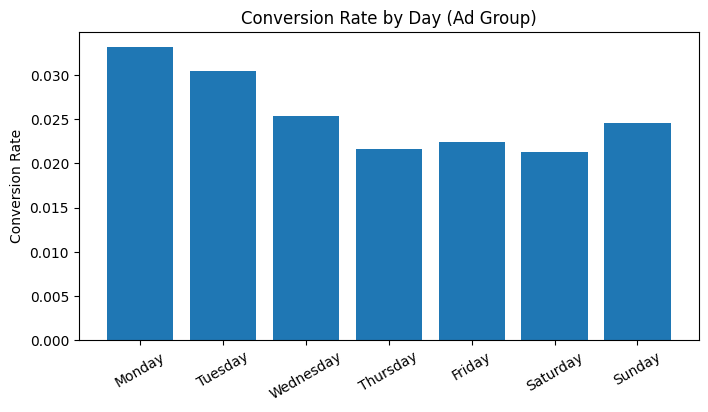

               conversion_rate  n_users
most_ads_hour                          
0                     0.019213     5309
1                     0.013434     4615
2                     0.007570     5152
3                     0.010425     2590
4                     0.015850      694
5                     0.021563      742
6                     0.023174     1985
7                     0.018482     6168
8                     0.019861    16968
9                     0.019529    29802
10                    0.021840    37454
11                    0.022469    44149
12                    0.024139    45238
13                    0.025063    45485
14                    0.028575    43779
15                    0.029845    42855
16                    0.030893    35963
17                    0.028537    33605
18                    0.027470    31052
19                    0.026809    29169
20                    0.030274    27846
21                    0.029175    28895
22                    0.026455    25515


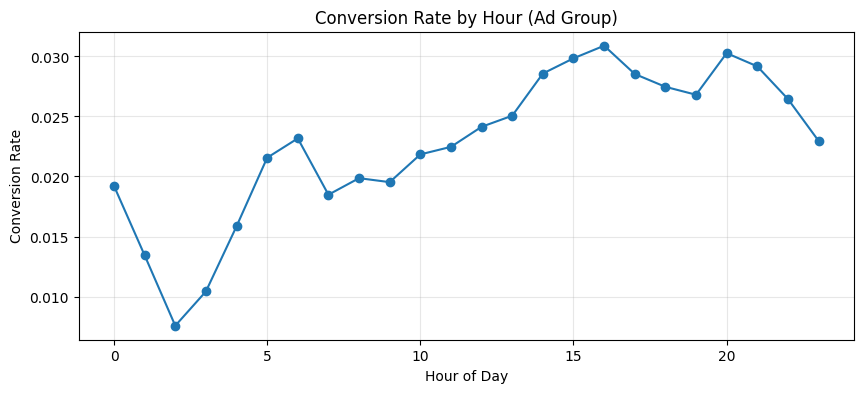

In [24]:
# Conversion rate by day
day_conv = ad_only.groupby('most_ads_day')['converted'].agg(['mean','count'])
day_conv.columns = ['conversion_rate','n_users']

# Order days properly (not alphabetical)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_conv = day_conv.reindex(day_order)
print(day_conv)

plt.figure(figsize=(8,4))
plt.bar(day_conv.index, day_conv['conversion_rate'])
plt.title('Conversion Rate by Day (Ad Group)')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=30)
plt.show()

# Conversion rate by hour
hour_conv = ad_only.groupby('most_ads_hour')['converted'].agg(['mean','count'])
hour_conv.columns = ['conversion_rate','n_users']
print(hour_conv)

plt.figure(figsize=(10,4))
plt.plot(hour_conv.index, hour_conv['conversion_rate'], marker='o')
plt.title('Conversion Rate by Hour (Ad Group)')
plt.xlabel('Hour of Day')
plt.ylabel('Conversion Rate')
plt.grid(alpha=0.3)
plt.show()

# 08. Analysis Output

### Prepare a Clean Dataset for Reuse

The final step is to export the cleaned dataset with the analysis-ready fields. This creates a reusable output for dashboards, further analysis, or business reporting without requiring the data-preparation steps to be repeated.


In [27]:
df.to_csv('marketing_AB_cleaned.csv', index=False)

# 09. Business Takeaway

This analysis is structured to answer four practical questions:

1. **Did advertising improve conversion compared with the PSA control group?**
2. **How does conversion change with increasing ad exposure?**
3. **Are conversions concentrated among highly exposed users?**
4. **Which days and hours show stronger conversion performance?**

Together, these analyses move from **campaign effectiveness** to **exposure efficiency** and finally to **timing optimization**, giving the business a clearer basis for deciding how advertising should be deployed.
